# Set Up Model

Install & Import Library

In [191]:
!pip install -q imbalanced-learn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os
from google.colab import drive

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set(style="whitegrid")

# Data Selection

Mount Drive & Load CSV

In [192]:
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/skripsi/Dataset/Data_siswa.csv"

df = pd.read_csv(dataset_path, sep=None, engine='python')

df.columns = df.columns.str.replace('\ufeff', '', regex=False)

print("Ukuran dataset:", df.shape)
display(df.head())
print("Jumlah data setelah load :", df.shape[0])
print("Jumlah kolom             :", df.shape[1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran dataset: (501, 14)


,ID_Siswa,Nama,Kelamin,Sekolah,Kelas,Nomor_Absen,Intensitas_Belajar,Fokus_Belajar,Disiplin_Belajar,Interaksi_Belajar,Teknologi,Lingkungan_Belajar,Waktu_Efektif,Gaya_Belajar
0,S1_3A_1,Abil Shidqi Arsalaan,Laki-laki,SDN Cicadas Girang,3A,1,Tinggi,Tinggi,Tinggi,Tinggi,Sedang,Tinggi,Siang,Visual
1,S1_3A_2,Adinda Adzani El-Zahra,Perempuan,SDN Cicadas Girang,3A,2,Tinggi,Tinggi,Tinggi,Sedang,Sedang,Sedang,Pagi,Auditori
2,S1_3A_3,Adinda Azani Putri Sopandi,Perempuan,SDN Cicadas Girang,3A,3,Rendah,Tinggi,Rendah,Sedang,Tinggi,Rendah,Malam,Auditori
3,S1_3A_4,Aira Syahraini Putri,Perempuan,SDN Cicadas Girang,3A,4,Tinggi,Tinggi,Tinggi,Sedang,Sedang,Sedang,Pagi,Auditori
4,S1_3A_5,Aisyah Nurul Hanifah,Perempuan,SDN Cicadas Girang,3A,5,Sedang,Sedang,Sedang,Sedang,Tinggi,Sedang,Pagi,Visual


Jumlah data setelah load : 501
Jumlah kolom             : 14


Validasi Dataset

In [193]:
required_columns = [
    "Intensitas_Belajar",
    "Fokus_Belajar",
    "Disiplin_Belajar",
    "Interaksi_Belajar",
    "Teknologi",
    "Lingkungan_Belajar",
    "Waktu_Efektif",
    "Gaya_Belajar"
]

missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan dalam dataset: {missing_cols}")
else:
    print("Semua kolom penting tersedia ✔")


Semua kolom penting tersedia ✔


Cek struktur dataset

In [194]:
feature_cols = [
    "Intensitas_Belajar",
    "Fokus_Belajar",
    "Disiplin_Belajar",
    "Interaksi_Belajar",
    "Teknologi",
    "Lingkungan_Belajar",
    "Waktu_Efektif"
]

target_col = "Gaya_Belajar"

tabel_variabel = pd.DataFrame({
    "No": range(1, len(feature_cols) + 2),
    "Variabel": feature_cols + [target_col],
    "Peran": ["Fitur"] * len(feature_cols) + ["Target"],
    "Tipe Data": ["Kategorikal"] * (len(feature_cols) + 1)
})

print("Tabel Variabel Penelitian:")
display(tabel_variabel)

Tabel Variabel Penelitian:


,No,Variabel,Peran,Tipe Data
0,1,Intensitas_Belajar,Fitur,Kategorikal
1,2,Fokus_Belajar,Fitur,Kategorikal
2,3,Disiplin_Belajar,Fitur,Kategorikal
3,4,Interaksi_Belajar,Fitur,Kategorikal
4,5,Teknologi,Fitur,Kategorikal
5,6,Lingkungan_Belajar,Fitur,Kategorikal
6,7,Waktu_Efektif,Fitur,Kategorikal
7,8,Gaya_Belajar,Target,Kategorikal


# Data Preparation

Data Cleaning

In [195]:
df_model = df.copy()

print("Jumlah data awal:", df_model.shape)

df_model = df_model.replace(r'^\s*$', np.nan, regex=True)

print("\nMissing value sebelum cleaning:")
print(df_model.isna().sum())

df_model = df_model.drop_duplicates().reset_index(drop=True)
print("\nJumlah baris duplikat: ",df.duplicated().sum())

print("\nJumlah data setelah hapus duplikat:", df_model.shape)

imputer = SimpleImputer(strategy='most_frequent')

df_model[feature_cols] = imputer.fit_transform(df_model[feature_cols])

print("\nMissing value setelah imputasi:")
print(df_model.isna().sum())
print("Jumlah data setelah cleaning :", df_model.shape[0])

Jumlah data awal: (501, 14)

Missing value sebelum cleaning:
ID_Siswa              0
Nama                  0
Kelamin               0
Sekolah               0
Kelas                 0
Nomor_Absen           0
Intensitas_Belajar    0
Fokus_Belajar         0
Disiplin_Belajar      0
Interaksi_Belajar     0
Teknologi             0
Lingkungan_Belajar    0
Waktu_Efektif         0
Gaya_Belajar          0
dtype: int64

Jumlah baris duplikat:  6

Jumlah data setelah hapus duplikat: (495, 14)

Missing value setelah imputasi:
ID_Siswa              0
Nama                  0
Kelamin               0
Sekolah               0
Kelas                 0
Nomor_Absen           0
Intensitas_Belajar    0
Fokus_Belajar         0
Disiplin_Belajar      0
Interaksi_Belajar     0
Teknologi             0
Lingkungan_Belajar    0
Waktu_Efektif         0
Gaya_Belajar          0
dtype: int64
Jumlah data setelah cleaning : 495


Drop Atribut Identitas

In [196]:
df_model = df_model.drop(
    columns=[
        'ID_Siswa',
        'Sekolah',
        'Nomor_Absen',
        'Nama',
        'Kelamin',
        'Kelas'
    ],
    errors='ignore'
)

print("Kolom setelah menghapus atribut identitas:")
print(df_model.columns.tolist())


Kolom setelah menghapus atribut identitas:
['Intensitas_Belajar', 'Fokus_Belajar', 'Disiplin_Belajar', 'Interaksi_Belajar', 'Teknologi', 'Lingkungan_Belajar', 'Waktu_Efektif', 'Gaya_Belajar']


Seleksi Fitur Model

In [197]:
feature_cols = [
    "Intensitas_Belajar",
    "Fokus_Belajar",
    "Disiplin_Belajar",
    "Interaksi_Belajar",
    "Teknologi",
    "Lingkungan_Belajar",
    "Waktu_Efektif"
]

target_col = "Gaya_Belajar"

df_model = df_model[feature_cols + [target_col]]

print("Struktur dataset setelah seleksi fitur:")
display(df_model.head())

Struktur dataset setelah seleksi fitur:


,Intensitas_Belajar,Fokus_Belajar,Disiplin_Belajar,Interaksi_Belajar,Teknologi,Lingkungan_Belajar,Waktu_Efektif,Gaya_Belajar
0,Tinggi,Tinggi,Tinggi,Tinggi,Sedang,Tinggi,Siang,Visual
1,Tinggi,Tinggi,Tinggi,Sedang,Sedang,Sedang,Pagi,Auditori
2,Rendah,Tinggi,Rendah,Sedang,Tinggi,Rendah,Malam,Auditori
3,Tinggi,Tinggi,Tinggi,Sedang,Sedang,Sedang,Pagi,Auditori
4,Sedang,Sedang,Sedang,Sedang,Tinggi,Sedang,Pagi,Visual


Encoding Target Label

In [198]:
X = df_model[feature_cols].copy()
y_raw = df_model[target_col].astype(str).copy()

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

mapping_df = pd.DataFrame({
    "Kelas Gaya Belajar": target_encoder.classes_,
    "Kode Numerik": range(len(target_encoder.classes_))
})

print("Mapping Label Encoding:")
display(mapping_df)

Mapping Label Encoding:


,Kelas Gaya Belajar,Kode Numerik
0,Auditori,0
1,Kinestetik,1
2,Visual,2


Split Data (70:30, Stratified)

In [199]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(" Ringkasan pembagian data 70:30 (stratified):")
display(tabel_split)


 Ringkasan pembagian data 70:30 (stratified):


,Dataset,Jumlah Data,Persentase (%)
0,Training,346,69.9
1,Testing,149,30.1
2,Total,495,100.0


Analisis Distribusi & Penentuan CV

In [200]:
train_dist = pd.Series(target_encoder.inverse_transform(y_train)).value_counts()
test_dist  = pd.Series(target_encoder.inverse_transform(y_test)).value_counts()

tabel_distribusi_train_test = pd.DataFrame({
    "Kelas": sorted(target_encoder.classes_),
    "Train": [int(train_dist.get(k, 0)) for k in sorted(target_encoder.classes_)],
    "Test":  [int(test_dist.get(k, 0)) for k in sorted(target_encoder.classes_)]
})

display(tabel_distribusi_train_test)

class_counts = pd.Series(y_train).value_counts().sort_index()
min_class = int(class_counts.min())
max_class = int(class_counts.max())
ratio = max_class / min_class

print("Distribusi kelas data latih:")
print(class_counts)
print("Rasio ketidakseimbangan:", round(ratio,2))

cv_folds = max(2, min(5, min_class))
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print("Jumlah fold cross-validation:", cv_folds)

,Kelas,Train,Test
0,Auditori,105,45
1,Kinestetik,55,24
2,Visual,186,80


Distribusi kelas data latih:
0    105
1     55
2    186
Name: count, dtype: int64
Rasio ketidakseimbangan: 3.38
Jumlah fold cross-validation: 5


Cek Imbalance dan Tentukan CV

In [201]:
class_counts = pd.Series(y_train).value_counts().sort_index()
min_class = int(class_counts.min())
max_class = int(class_counts.max())
ratio = (max_class / min_class) if min_class > 0 else 0

print("Distribusi kelas pada data latih:")
print(class_counts)

print(f"\nJumlah data kelas minimum : {min_class}")
print(f"Jumlah data kelas maksimum: {max_class}")
print(f"Rasio ketidakseimbangan   : {ratio:.2f}")

cv_folds = max(2, min(5, min_class))
cv = StratifiedKFold(
    n_splits=cv_folds,
    shuffle=True,
    random_state=42
)


Distribusi kelas pada data latih:
0    105
1     55
2    186
Name: count, dtype: int64

Jumlah data kelas minimum : 55
Jumlah data kelas maksimum: 186
Rasio ketidakseimbangan   : 3.38


# Modeling RF

Pipeline Preprocessing (Imputer + OrdinalEncoder) + RF + Review Transformasi

In [202]:
preprocess_steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
]

preprocess_pipeline = Pipeline(steps=preprocess_steps)

preprocess_view = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

X_view = df_model[feature_cols]
X_transformed = preprocess_view.fit_transform(X_view)

df_transformed = pd.DataFrame(X_transformed, columns=feature_cols)

print("Contoh hasil transformasi fitur (5 data):")
display(df_transformed.head())

Contoh hasil transformasi fitur (5 data):


,Intensitas_Belajar,Fokus_Belajar,Disiplin_Belajar,Interaksi_Belajar,Teknologi,Lingkungan_Belajar,Waktu_Efektif
0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
1,2.0,2.0,2.0,1.0,1.0,1.0,1.0
2,0.0,2.0,0.0,1.0,2.0,0.0,0.0
3,2.0,2.0,2.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,2.0,1.0,1.0


Random Forest Model

In [203]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("Parameter awal Random Forest:")
print(rf)

Parameter awal Random Forest:
RandomForestClassifier(n_jobs=-1, random_state=42)


Integrasi ke Pipeline

In [204]:
pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ("rf", rf)
])

print("Pipeline model:")
for name, _ in pipeline.steps:
    print("-", name)

Pipeline model:
- imputer
- encoder
- rf


Hyperparameter Tuning (StratifiedKFold + RandomizedSearchCV)

In [205]:
param_dist = {
    "rf__n_estimators": [100, 150, 200],
    "rf__max_depth": [None, 10, 15, 20],
    "rf__min_samples_split": [2, 3, 5],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Proses tuning dimulai...")
search.fit(X_train, y_train)

best_model = search.best_estimator_

Proses tuning dimulai...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [206]:
param_desc = {
    "rf__n_estimators": "Jumlah pohon keputusan dalam Random Forest",
    "rf__max_depth": "Kedalaman maksimum setiap pohon",
    "rf__min_samples_split": "Minimum jumlah data untuk membentuk percabangan",
    "rf__min_samples_leaf": "Minimum jumlah data pada daun pohon",
    "rf__max_features": "Jumlah fitur yang dipertimbangkan pada setiap percabangan"
}

rows = []
for param, values in param_dist.items():
    rows.append({
        "Parameter": param.replace("rf__", ""),
        "Rentang Nilai yang Diuji": ", ".join([str(v) for v in values]),
        "Keterangan": param_desc.get(param, "-")
    })

tabel_param = pd.DataFrame(rows)

print("Tabel parameter yang dioptimasi:")
display(tabel_param)

Tabel parameter yang dioptimasi:


,Parameter,Rentang Nilai yang Diuji,Keterangan
0,n_estimators,"100, 150, 200",Jumlah pohon keputusan dalam Random Forest
1,max_depth,"None, 10, 15, 20",Kedalaman maksimum setiap pohon
2,min_samples_split,"2, 3, 5",Minimum jumlah data untuk membentuk percabangan
3,min_samples_leaf,"1, 2, 4",Minimum jumlah data pada daun pohon
4,max_features,"sqrt, log2",Jumlah fitur yang dipertimbangkan pada setiap ...


Hasil Parameter Terbaik

In [207]:
print("\nBest Parameters Random Forest:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

print(f"\nBest CV F1-macro: {search.best_score_:.4f}")


Best Parameters Random Forest:
rf__n_estimators: 100
rf__min_samples_split: 5
rf__min_samples_leaf: 4
rf__max_features: log2
rf__max_depth: 20

Best CV F1-macro: 0.7952


# Evaluasi Model

Prediksi Data Uji

In [208]:
y_pred = best_model.predict(X_test)

print("Jumlah data uji:", len(y_test))

Jumlah data uji: 149


Performance Metrics

In [209]:
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {acc*100:.2f}%")
print(f"F1-score : {f1m:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_,
    digits=4
))

Accuracy : 85.91%
F1-score : 0.8341

Classification Report:
              precision    recall  f1-score   support

    Auditori     0.9444    0.7556    0.8395        45
  Kinestetik     0.8500    0.7083    0.7727        24
      Visual     0.8280    0.9625    0.8902        80

    accuracy                         0.8591       149
   macro avg     0.8741    0.8088    0.8341       149
weighted avg     0.8667    0.8591    0.8560       149



 Confusion Matriks

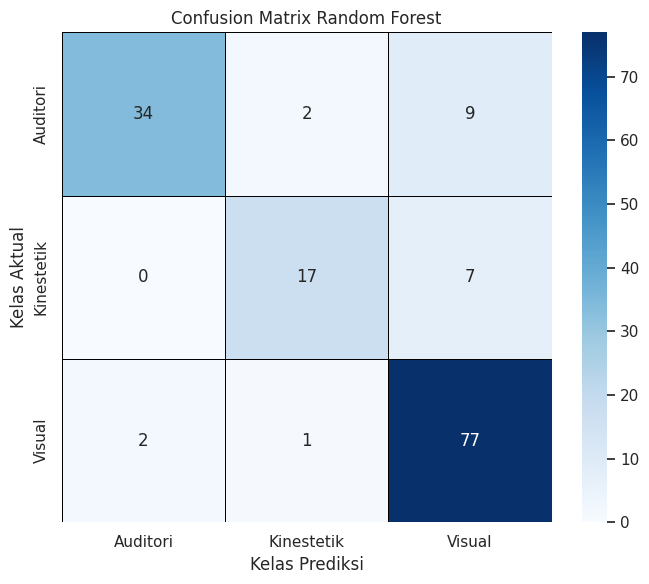

Kelas: ['Auditori', 'Kinestetik', 'Visual']


In [210]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='black',
    cbar=True,
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Kelas Prediksi")
plt.ylabel("Kelas Aktual")
plt.title("Confusion Matrix Random Forest")
plt.tight_layout()
plt.show()
print("Kelas:", list(target_encoder.classes_))

 Feature Importance (Tabel + Grafik)

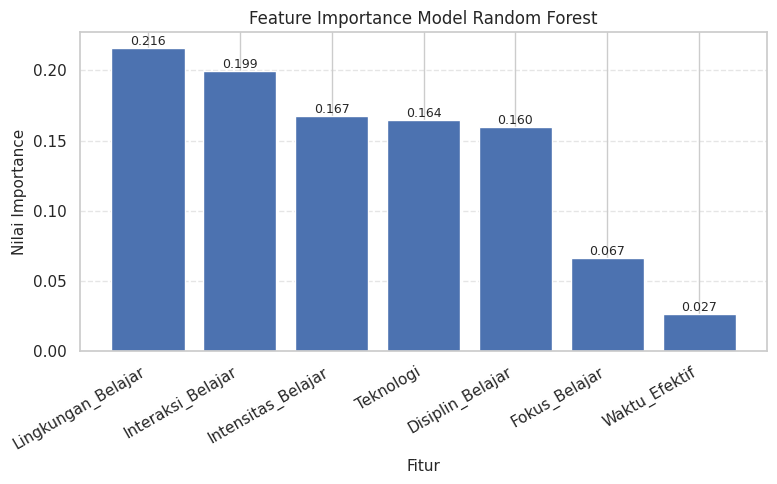


Feature Importance Random Forest:


,Fitur,Nilai Importance
5,Lingkungan_Belajar,0.216197
3,Interaksi_Belajar,0.199250
0,Intensitas_Belajar,0.167177
4,Teknologi,0.164295
2,Disiplin_Belajar,0.159604
1,Fokus_Belajar,0.066623
6,Waktu_Efektif,0.026855


In [211]:
importances = best_model.named_steps['rf'].feature_importances_

fi_df = pd.DataFrame({
    "Fitur": X.columns,
    "Nilai Importance": importances
}).sort_values(by="Nilai Importance", ascending=False)


plt.figure(figsize=(8,5))
bars = plt.bar(
    fi_df["Fitur"],
    fi_df["Nilai Importance"]
)

plt.title("Feature Importance Model Random Forest", fontsize=12)
plt.xlabel("Fitur", fontsize=11)
plt.ylabel("Nilai Importance", fontsize=11)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nFeature Importance Random Forest:")
display(fi_df)



 Grafik Skor Cross Validation

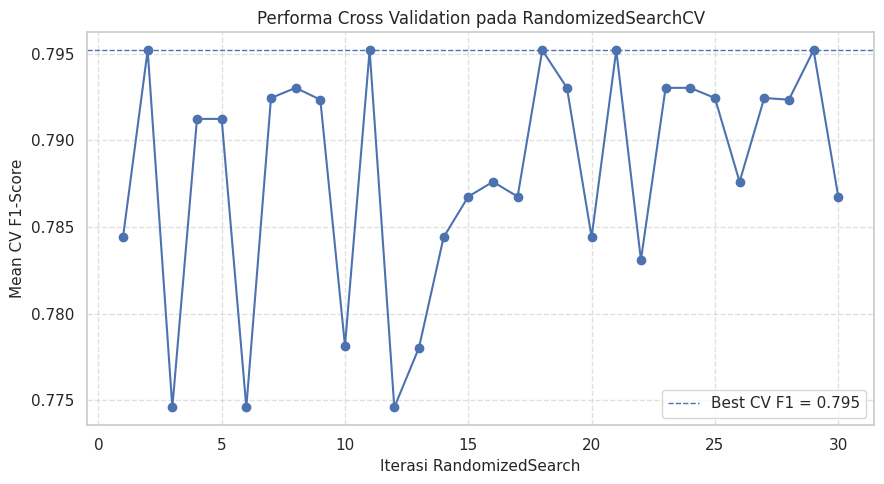

In [212]:
mean_scores = search.cv_results_['mean_test_score']

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(mean_scores) + 1),
    mean_scores,
    marker='o',
    linestyle='-'
)

plt.xlabel("Iterasi RandomizedSearch", fontsize=11)
plt.ylabel("Mean CV F1-Score", fontsize=11)
plt.title("Performa Cross Validation pada RandomizedSearchCV", fontsize=12)

best_score = search.best_score_
plt.axhline(
    y=best_score,
    linestyle='--',
    linewidth=1,
    label=f"Best CV F1 = {best_score:.3f}"
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [213]:
drive.mount('/content/drive')
output_dir = "/content/drive/MyDrive/skripsi/Model"
os.makedirs(output_dir, exist_ok=True)

artifact = {
    "model": best_model,
    "feature_cols": feature_cols,
    "target_encoder": target_encoder,
    "target_classes": target_encoder.classes_
}

model_path = os.path.join(output_dir, "model_rf_gaya_belajar1.joblib")
joblib.dump(artifact, model_path)

print(f"Model berhasil disimpan di: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model berhasil disimpan di: /content/drive/MyDrive/skripsi/Model/model_rf_gaya_belajar1.joblib
